# **Memory decoding and nonlinear dynamical model of spike trains**


## 4.1 Decoding

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


### 4.1.1 Feature Extraction

In [4]:
spikes = np.load("spike_data.npy", allow_pickle=True).item()
events = np.load("selected_events.npy", allow_pickle=True).item()

Here we define each bin using a width of 50 ms and window size of 1.5 s before and after the onset of each event. This allows us to find the firing rate by counting the number of spikes in each bin. 

In [5]:
for k in spikes:
    spikes[k] = np.array(spikes[k])
for k in events:
    events[k] = np.array(events[k])

bin_size = 0.05
window = (-1.5, 1.5)
bins = np.arange(window[0], window[1] + bin_size, bin_size)
bin_centers = bins[:-1] + bin_size / 2


We then define our labels and features from the datasest. X and Y are built across all trial types. 

In [6]:
neurons = ['CA3_1','CA3_2','CA3_3','CA3_4','CA3_5','CA3_6',
           'CA1_1','CA1_2','CA1_3','CA1_4','CA1_5']

event_names = ['A_NONMATCH', 'A_SAMPLES', 'B_NONMATCH', 'B_SAMPLES']
n_neurons = len(neurons)
n_bins    = len(bin_centers)

all_X = []
all_y = []

for label, event_name in enumerate(event_names):
    event_times = events[event_name]
    n_trials = len(event_times)

    X_event = np.zeros((n_trials, n_neurons, n_bins))

    for t, t_onset in enumerate(event_times):
        for n, neuron in enumerate(neurons):
            aligned = spikes[neuron] - t_onset
            in_window = aligned[(aligned >= window[0]) & (aligned <= window[1])]
            counts, _ = np.histogram(in_window, bins=bins)
            X_event[t, n, :] = counts / bin_size

    all_X.append(X_event)
    all_y.append(np.full(n_trials, label))

X = np.vstack(all_X)
y = np.concatenate(all_y)
X_flat = X.reshape(len(X), -1)

print(X.shape, y.shape)  # (total_trials, 11, 60), (total_trials,)

(165, 11, 60) (165,)


### 4.1.2 Logistic Regression Classifier

A simple logistic classifier is built for initial results. A few modifiers to the classifier are added to improve its accuracy and other metrics.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=11)

In [8]:
clf = LogisticRegression()

In [9]:
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [10]:
y_pred = clf.predict(X_test)

In [11]:
clf.score(X_test, y_test)

0.3333333333333333

In [12]:
print(confusion_matrix(y_test, y_pred))

[[3 0 2 1]
 [0 4 1 8]
 [2 0 3 0]
 [2 4 2 1]]


In [13]:
print(classification_report(y_test, y_pred, target_names=event_names))

              precision    recall  f1-score   support

  A_NONMATCH       0.43      0.50      0.46         6
   A_SAMPLES       0.50      0.31      0.38        13
  B_NONMATCH       0.38      0.60      0.46         5
   B_SAMPLES       0.10      0.11      0.11         9

    accuracy                           0.33        33
   macro avg       0.35      0.38      0.35        33
weighted avg       0.36      0.33      0.33        33



### 4.1.3 Evaluation: Improving classifier via temporal cv and scaling

We improve upon our first classifier by adding temporal cross validation and scaling. Since we want to avoid data leakage from cross validation that utilizes random splits and overlapping windows, this is the most optimal solution.

In [14]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [15]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

In [16]:
shuffle_idx = np.random.RandomState(42).permutation(len(X_flat))
X_shuffled = X_flat[shuffle_idx]
y_shuffled = y[shuffle_idx]

In [17]:
tscv = TimeSeriesSplit(n_splits=3)  # fewer splits = larger training sets per fold
scores = cross_val_score(pipeline, X_shuffled, y_shuffled, cv=tscv)
print(f"Temporal CV accuracy: {scores.mean():.2f} ± {scores.std():.2f}")


Temporal CV accuracy: 0.44 ± 0.05


In [18]:
tscv = TimeSeriesSplit(n_splits=5)
all_preds = []
all_true = []

for train_idx, test_idx in tscv.split(X_shuffled):
    X_train, X_test = X_shuffled[train_idx], X_shuffled[test_idx]
    y_train, y_test = y_shuffled[train_idx], y_shuffled[test_idx]
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)
    
    all_preds.extend(clf.predict(X_test))
    all_true.extend(y_test)

print(confusion_matrix(all_true, all_preds))
print(classification_report(all_true, all_preds, target_names=event_names))

[[24  1  2  2]
 [10 16  4 17]
 [16  1  3  1]
 [13 10  2 13]]
              precision    recall  f1-score   support

  A_NONMATCH       0.38      0.83      0.52        29
   A_SAMPLES       0.57      0.34      0.43        47
  B_NONMATCH       0.27      0.14      0.19        21
   B_SAMPLES       0.39      0.34      0.37        38

    accuracy                           0.41       135
   macro avg       0.40      0.41      0.38       135
weighted avg       0.43      0.41      0.39       135



## 4.2 Functional Connectivity Modeling

### 4.2.1 B-spline Basis Expansion

Spike train -> Time function -> projection onto B-splines -> features

In [19]:
from scipy.interpolate import BSpline
import numpy as np

# Neurons we need
input_neurons = ['CA3_1', 'CA3_2']
output_neuron = 'CA1_2'

# Use all 4 event types combined (same as part 1)
all_events = np.concatenate([events[e] for e in event_names])
n_trials = len(all_events)
n_bins = len(bin_centers)

# Extract firing rates for CA3_1, CA3_2, CA1_2
def get_firing_rates(neuron, event_times):
    FR = np.zeros((len(event_times), n_bins))
    for t, t_onset in enumerate(event_times):
        aligned = spikes[neuron] - t_onset
        in_window = aligned[(aligned >= window[0]) & (aligned <= window[1])]
        counts, _ = np.histogram(in_window, bins=bins)
        FR[t, :] = counts / bin_size
    return FR  # shape: (n_trials, n_bins)

FR_CA3_1 = get_firing_rates('CA3_1', all_events)  # (n_trials, 60)
FR_CA3_2 = get_firing_rates('CA3_2', all_events)  # (n_trials, 60)
FR_CA1_2 = get_firing_rates('CA1_2', all_events)  # (n_trials, 60)

print(FR_CA3_1.shape, FR_CA3_2.shape, FR_CA1_2.shape)

(165, 60) (165, 60) (165, 60)


In [20]:
n_lags = 4  # 0 to 200ms in 50ms steps

def build_lagged(FR, n_lags):
    """
    For each time bin j, stack the past n_lags bins as additional features.
    Output shape: (n_trials, n_bins, n_lags+1)
    """
    n_trials, n_bins = FR.shape
    lagged = np.zeros((n_trials, n_bins, n_lags + 1))
    
    for lag in range(n_lags + 1):
        if lag == 0:
            lagged[:, :, lag] = FR
        else:
            # shift forward by lag, pad beginning with zeros
            lagged[:, lag:, lag] = FR[:, :-lag]
    
    return lagged  # (165, 60, 5)

lagged_CA3_1 = build_lagged(FR_CA3_1, n_lags)  # (165, 60, 5)
lagged_CA3_2 = build_lagged(FR_CA3_2, n_lags)  # (165, 60, 5)

print(lagged_CA3_1.shape)  # (165, 60, 5)

(165, 60, 5)


In [21]:
from scipy.interpolate import BSpline
import numpy as np

# Define B-spline basis over lag positions 0 to n_lags
n_basis = 5      # number of basis functions
order = 4        # cubic spline (order = degree + 1)
lag_points = np.arange(n_lags + 1)  # [0, 1, 2, 3, 4]

# Create knots — must have n_basis + order total knots
n_knots = n_basis + order
knots = np.linspace(lag_points[0], lag_points[-1], n_knots)

# Evaluate each basis function at each lag point
# B has shape (n_lags+1, n_basis)
B = np.array([
    BSpline.basis_element(knots[i:i+order+1])(lag_points)
    for i in range(n_basis)
]).T  # (5, 5)

print(f"B-spline basis shape: {B.shape}")  # (5, 5)

# Apply basis expansion: z = lagged @ B
# lagged: (165, 60, 5) @ B: (5, 5) → z: (165, 60, 5)
def apply_bspline(lagged, B):
    return lagged @ B  # (n_trials, n_bins, n_basis)

z_CA3_1 = apply_bspline(lagged_CA3_1, B)  # (165, 60, 5)
z_CA3_2 = apply_bspline(lagged_CA3_2, B)  # (165, 60, 5)

print(f"z_CA3_1 shape: {z_CA3_1.shape}")
print(f"z_CA3_2 shape: {z_CA3_2.shape}")

B-spline basis shape: (5, 5)
z_CA3_1 shape: (165, 60, 5)
z_CA3_2 shape: (165, 60, 5)


In [22]:
# Flatten trials and time bins together: (165, 60, 5) → (165*60, 5)
def flatten_features(z):
    n_trials, n_bins, n_basis = z.shape
    return z.reshape(n_trials * n_bins, n_basis)

# Input features for each model
X1 = flatten_features(z_CA3_1)                          # Model 1: CA3_1 only (9900, 5)
X2 = flatten_features(z_CA3_2)                          # Model 2: CA3_2 only (9900, 5)
X3 = np.hstack([flatten_features(z_CA3_1),
                flatten_features(z_CA3_2)])              # Model 3: both       (9900, 10)

# Target: CA1_2 spike counts (binary — did it spike in this bin?)
y_cont = FR_CA1_2.reshape(-1)                           # (9900,) continuous firing rate
y_binary = (y_cont > 0).astype(int)                     # (9900,) binary spike/no spike

print(X1.shape, X2.shape, X3.shape)
print(y_binary.shape)
print(f"Spike rate: {y_binary.mean():.2f}")             # fraction of bins with a spike

(9900, 5) (9900, 5) (9900, 10)
(9900,)
Spike rate: 0.01


In [23]:
# Rebuild target using raw spike counts (not firing rates)
def get_spike_counts(neuron, event_times):
    counts_all = np.zeros((len(event_times), n_bins))
    for t, t_onset in enumerate(event_times):
        aligned = spikes[neuron] - t_onset
        in_window = aligned[(aligned >= window[0]) & (aligned <= window[1])]
        counts, _ = np.histogram(in_window, bins=bins)
        counts_all[t, :] = counts  # raw counts, not divided by bin_size
    return counts_all

counts_CA1_2 = get_spike_counts('CA1_2', all_events)  # (165, 60)
y_binary = (counts_CA1_2.reshape(-1) > 0).astype(int)

print(f"Spike rate: {y_binary.mean():.2f}")
print(f"Spikes: {y_binary.sum()}, No spikes: {(y_binary==0).sum()}")

Spike rate: 0.01
Spikes: 94, No spikes: 9806


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss

def evaluate_model(X, y, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    ce_scores = []
    
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        clf = LogisticRegression(class_weight='balanced', max_iter=1000)
        clf.fit(X_train, y_train)
        
        y_proba = clf.predict_proba(X_test)
        ce = log_loss(y_test, y_proba)
        ce_scores.append(ce)
    
    return np.mean(ce_scores), np.std(ce_scores)

ce1_mean, ce1_std = evaluate_model(X1, y_binary)
ce2_mean, ce2_std = evaluate_model(X2, y_binary)
ce3_mean, ce3_std = evaluate_model(X3, y_binary)

print(f"Model 1 (CA3_1 only):      CE = {ce1_mean:.4f} ± {ce1_std:.4f}")
print(f"Model 2 (CA3_2 only):      CE = {ce2_mean:.4f} ± {ce2_std:.4f}")
print(f"Model 3 (CA3_1 + CA3_2):   CE = {ce3_mean:.4f} ± {ce3_std:.4f}")

Model 1 (CA3_1 only):      CE = 0.6771 ± 0.0086
Model 2 (CA3_2 only):      CE = 0.6336 ± 0.0269
Model 3 (CA3_1 + CA3_2):   CE = 0.6185 ± 0.0345


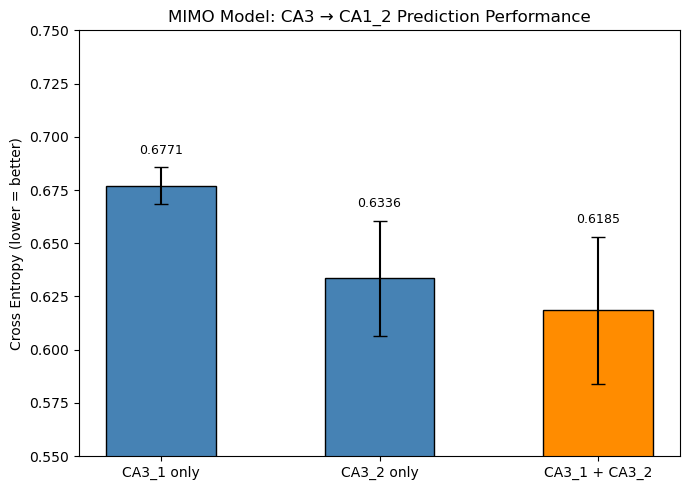

: 

In [ ]:
import matplotlib.pyplot as plt

models = ['CA3_1 only', 'CA3_2 only', 'CA3_1 + CA3_2']
means = [ce1_mean, ce2_mean, ce3_mean]
stds = [ce1_std, ce2_std, ce3_std]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(models, means, yerr=stds, capsize=5,
              color=['steelblue', 'steelblue', 'darkorange'],
              edgecolor='black', width=0.5)

ax.set_ylabel('Cross Entropy (lower = better)')
ax.set_title('MIMO Model: CA3 → CA1_2 Prediction Performance')
ax.set_ylim(0.55, 0.75)

# Annotate bars with values
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.005,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('mimo_cross_entropy.png', dpi=150)
plt.show()